In [ ]:
import kagglehub
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

Using Colab cache for faster access to the 'telco-customer-churn' dataset.


In [ ]:
import os

print(path)
print(os.listdir(path))

/kaggle/input/telco-customer-churn
['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [ ]:
import pandas as pd

file_path = path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv"


#Customer Churn Analysis

##Dataset Information : Sample dataset conatining customer data and showing Customers who Churned last month

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
import seaborn as sns
import matplotlib.ticker as mtick

#Load the data

In [ ]:
df = pd.read_csv(file_path)

In [ ]:
df.head(5) # top 5 records

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Check the various attributes of data like shape, rows and columns, datatype

In [ ]:
df.shape

(7043, 21)

In [ ]:
df.columns.values    #column values to know how many columns you have

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

Total charges should be a numerical values integer value. so we keep this in the mind and we will edit it in later process

In [ ]:
df.dtypes # special method but can you df.info() as well

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


Senior citizen has values 0-1 hence dataset says it an numerical attribute but it should be a categorical attribute with yes and no not 0 and 1, Hence we can ignore this box of senior citizen and only conider the part of tenure and montly charges

In [ ]:
df.describe()  #check the descriptive statistics of numerical variables

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.info() # to check for null values and it doesnt have anull values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()  #check the descriptive statistics of numerical variables

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Senior citizen is actually a catergorical hence 25%-50%-75% distibution is not proper

75% customers have tenure less than 55 months, also ,maybe has very less outliers as there is not much dffernce between mean and median of tenure

Average Montly charges are USD 64.76 whereas 75% customers pay more than USD  89.85 per month

In [ ]:
df['Churn'].value_counts()


,count
Churn,
No,5174
Yes,1869


In [ ]:
df['Churn'].value_counts()/len(df) * 100

,count
Churn,
No,73.463013
Yes,26.536987


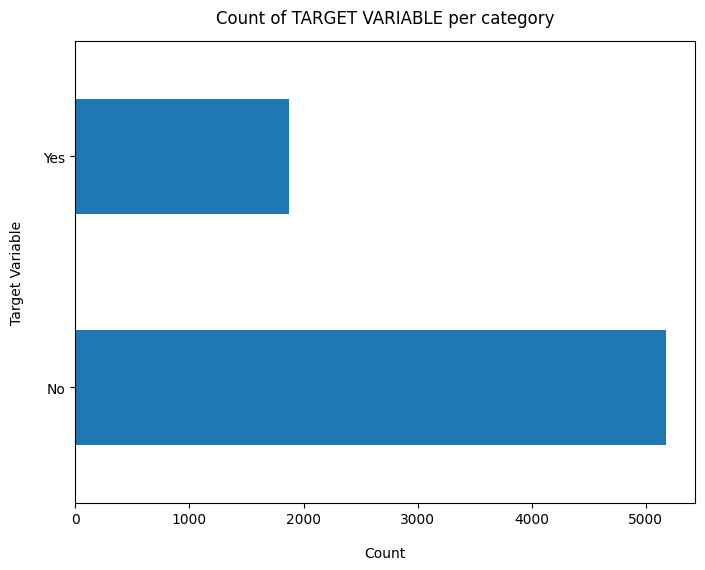

In [ ]:
df['Churn'].value_counts().plot(kind='barh',figsize=(8,6))
plt.xlabel('Count',labelpad=14)
plt.ylabel("Target Variable",labelpad=14)
plt.title("Count of TARGET VARIABLE per category",y=1.02);

Data is highly imbalanced, ratio = 73:27

so we analyse the data with other features while taking the target values seperatley to get some insights

In [ ]:
df.info() #concise summary of dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Total charges shows a Dtype of object but it should be a numerical/integer value and since it shows object Dtype it may or maynot contain NULL values cause in object Dtype NULL vlaues can also be considered as string but in numerical NULL vlaues are not cnsidered as Not NULL, hence qe have to change the Dtype of total charges and check again for info and NULL vlaues and If at all it has NULL value we try to impute the vlaues or fillna() those values.

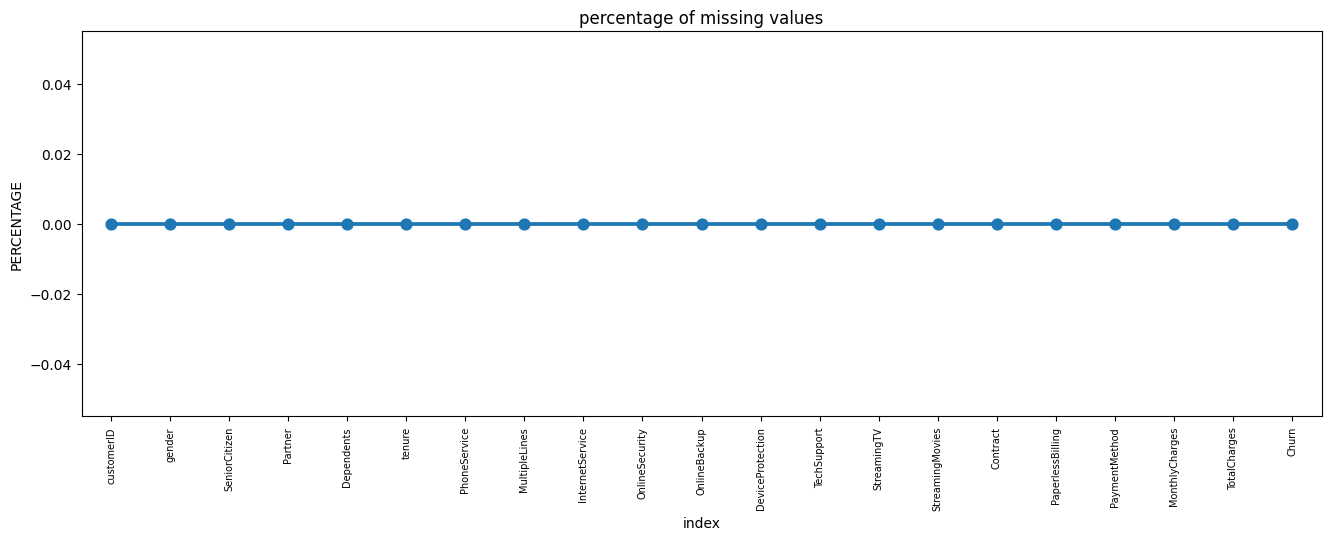

In [ ]:
missing = pd.DataFrame((df.isnull().sum())*100/df.shape[0]).reset_index()
plt.figure(figsize=(16,5))
ax = sns.pointplot(x='index', y=0, data=missing)
plt.xticks(rotation=90,fontsize=7)
plt.title("percentage of missing values")
plt.ylabel("PERCENTAGE")
plt.show()

# Missing data Intition Intution
  here , we dont have any missing data

##  General THumb Rules:
  for features with less missing vlaues, we can use regression to prediit the missing vlaues or fill with the mean of the vlaues present, depending on the feature.

  for features with very high number of missing vlaues, it is better to drop those columns asthey give very less insights on analysis

  as there is no thumb rule on what criteria do we dlete the columns with high number of misisng vaues , but generally you can delete the columns if you have more than 30-40% of misisng vlaues, but again there s a catch here for example is_car and car_type people having no cars, will obviously have car_type as NaN(NULL) , but that doesnt make the column uselss, so descions has to be taken wisely

#Data Cleaning

1. Create a copy of the base data for manuplation and processing

In [ ]:
new_df = df.copy()

2. Conversion of total charges

In [ ]:
new_df.TotalCharges = pd.to_numeric(new_df.TotalCharges,errors='coerce')
new_df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


11 NULL values found in Total Charges

3. Check the NULL records

In [ ]:
new_df.loc[new_df['TotalCharges'].isnull() == True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


4. Missing value treatment, since the percentage % of these records compared to total dataset is very low that is 0.15%(np.float64(0.1561834445548772)) , it is safe to ignore tem from further processing.

In [ ]:
percentage = new_df['TotalCharges'].isnull().sum()/len(new_df) * 100
percentage

np.float64(0.1561834445548772)

In [ ]:
new_df.dropna(how= 'any',inplace =True)

In [ ]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

5. Divide customers into bins based on tenure eg for tneure < 12 months assign a tenure group if 1-12, for enure bertween 1-2 yeras, tenure group of 13-24 and so on

In [ ]:
print(new_df['tenure'].max())

72


In [ ]:
labels = ["{0} - {1}" . format(i , i + 11) for i in range(1,72,12)]
print(labels)

['1 - 12', '13 - 24', '25 - 36', '37 - 48', '49 - 60', '61 - 72']


In [ ]:
# Group the tenure in bins of 12 months
new_df['tenure_group'] = pd.cut(new_df.tenure, range(1,80,12), right =False ,labels=labels)

In [ ]:
new_df['tenure_group'].value_counts()

,count
tenure_group,
1 - 12,2175
61 - 72,1407
13 - 24,1024
25 - 36,832
49 - 60,832
37 - 48,762


6. Remove columns not required for preocessing

In [ ]:
new_df.drop(columns=['customerID','tenure'],axis=1,inplace=True)

In [ ]:
new_df.head(5)

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1 - 12


# Data Exploration
(assuming that our data is cleaned for now)

1. Plot Distribution of individual predictors by Churn

#Univariate analysis

In [ ]:
new_df.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1 - 12


Senior citizens are more likely to churn (first raw insights)


people with no partners churn (second raw insights)

Montly contacts churn

people who pay by electronic check are churners


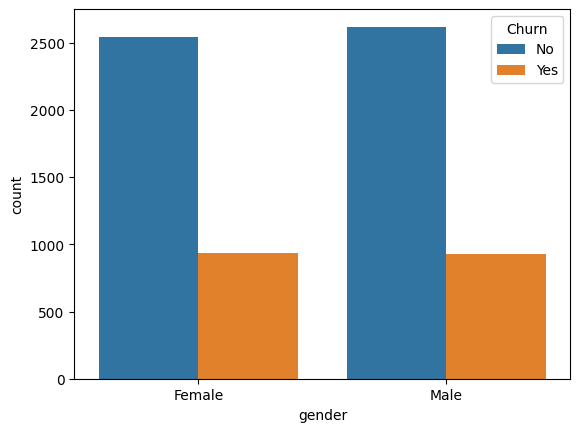

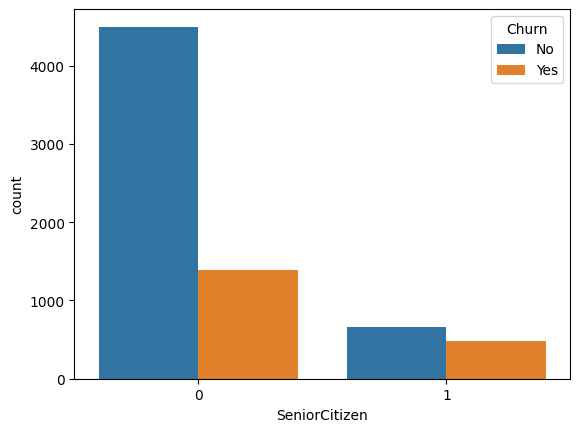

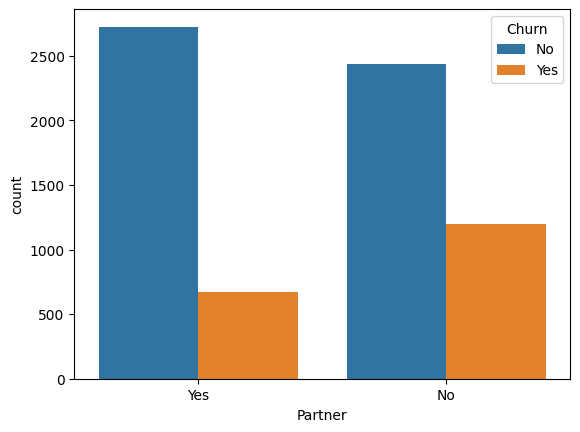

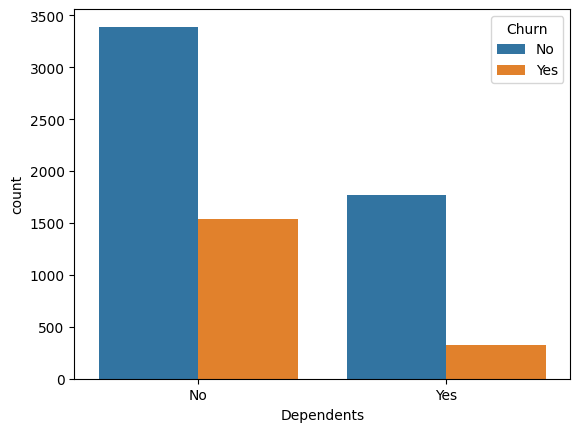

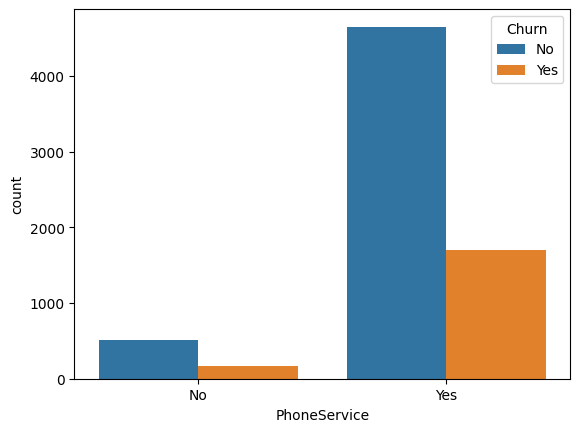

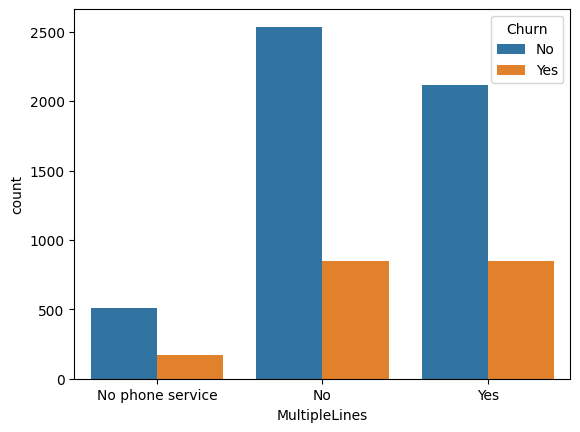

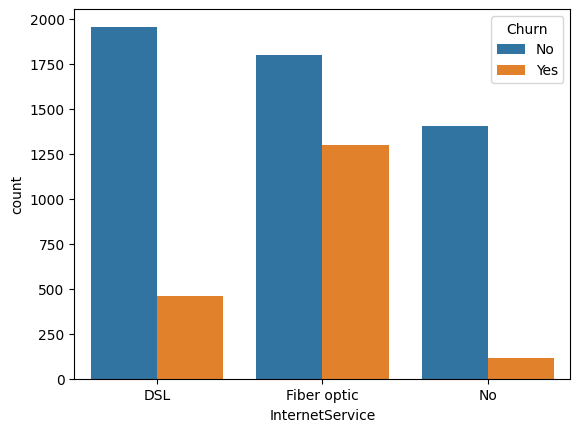

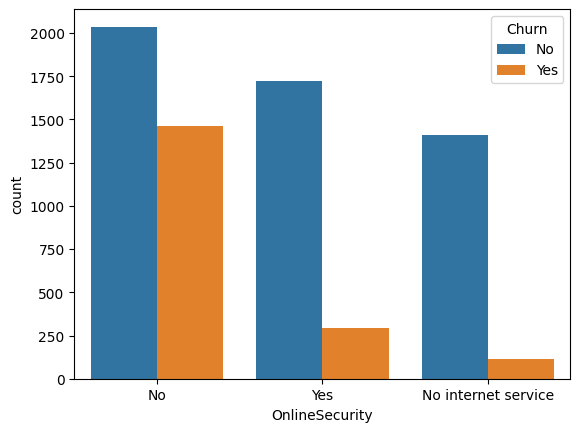

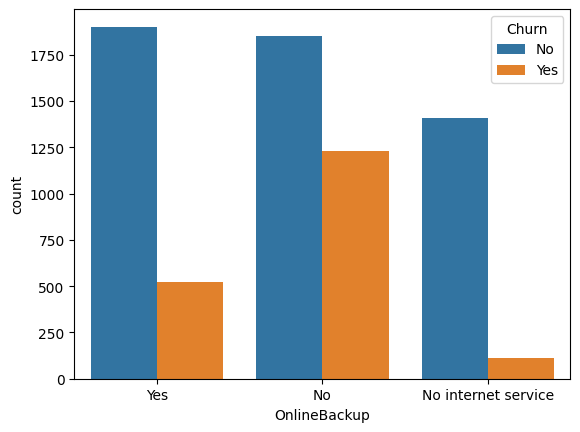

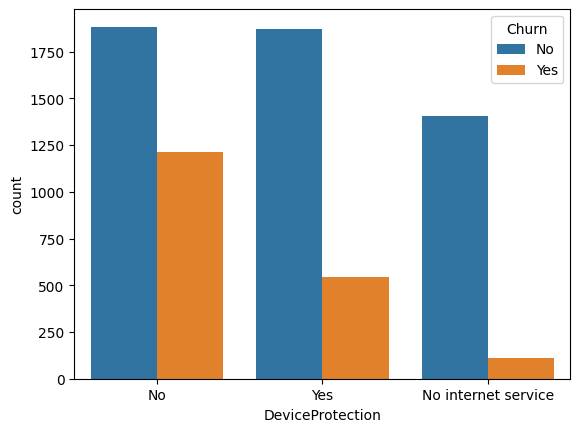

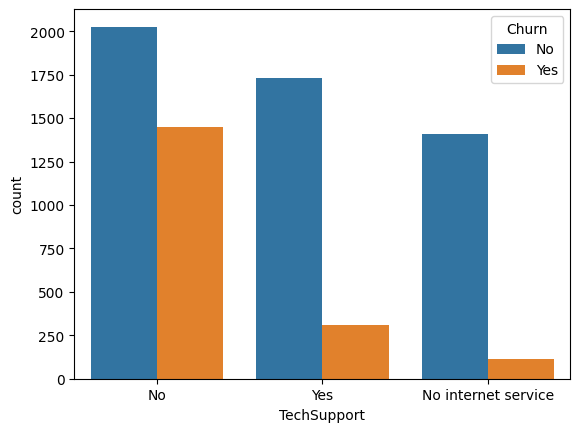

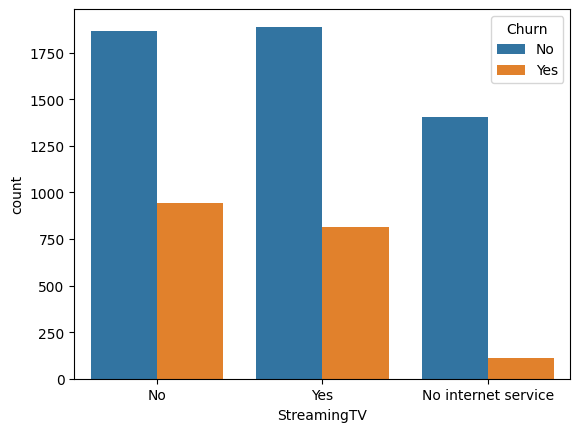

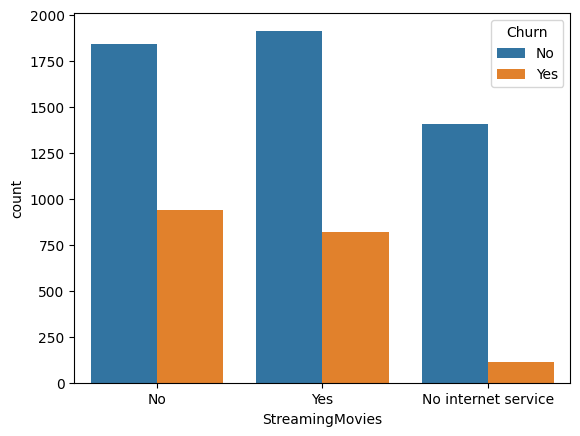

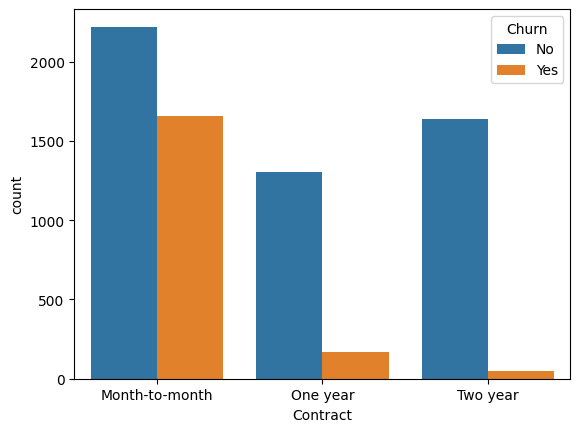

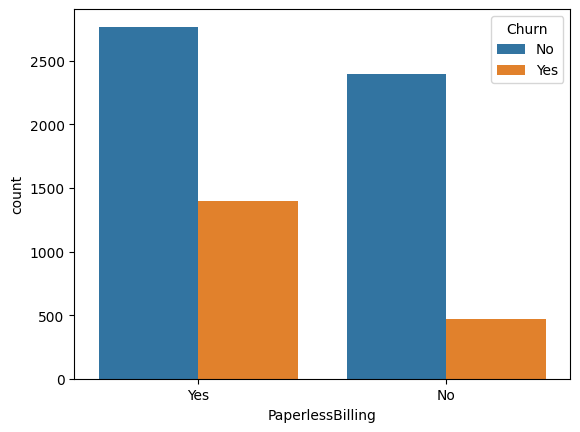

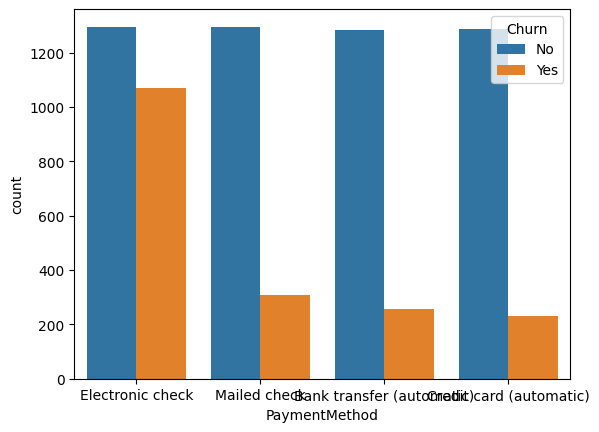

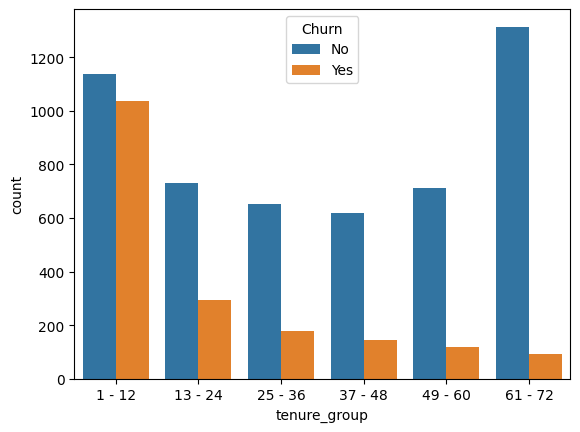

In [ ]:
for i, predictor in enumerate(new_df.drop(columns=['Churn','TotalCharges','MonthlyCharges'])): #numerical column and churn column y variable is deleted
  plt.figure(i)
  sns.countplot(data=new_df, x=predictor, hue='Churn')

#Numerical analysis

In [ ]:
new_df.gender.value_counts()

,count
gender,
Male,3549
Female,3483


In [ ]:
new_df1_target0 = new_df[new_df['Churn']== 'No']
new_df1_target1 = new_df[new_df['Churn']== 'Yes']

In [ ]:
new_df1_target1.gender.value_counts() #ratio is almost 1:1

,count
gender,
Female,939
Male,930


In [ ]:
pd.crosstab(new_df.PaymentMethod,new_df.Churn)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


2. Covnert the target variable 'Churn" in a binary numeric variable that is Yes=1 , no=0

In [ ]:
new_df['Churn'] = np.where(new_df.Churn == 'Yes' ,1 ,0)

In [ ]:
new_df.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1 - 12


3.  converting all the categorical variables into dummy variables

In [ ]:
new_df_dummies = pd.get_dummies(new_df)
new_df_dummies.head(5)

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1 - 12,tenure_group_13 - 24,tenure_group_25 - 36,tenure_group_37 - 48,tenure_group_49 - 60,tenure_group_61 - 72
0,0,29.85,29.85,0,True,False,False,True,True,False,...,False,False,True,False,True,False,False,False,False,False
1,0,56.95,1889.50,0,False,True,True,False,True,False,...,False,False,False,True,False,False,True,False,False,False
2,0,53.85,108.15,1,False,True,True,False,True,False,...,False,False,False,True,True,False,False,False,False,False
3,0,42.30,1840.75,0,False,True,True,False,True,False,...,True,False,False,False,False,False,False,True,False,False
4,0,70.70,151.65,1,True,False,True,False,True,False,...,False,False,True,False,True,False,False,False,False,False


 Realtionship between Montly Charges and Toatl charges

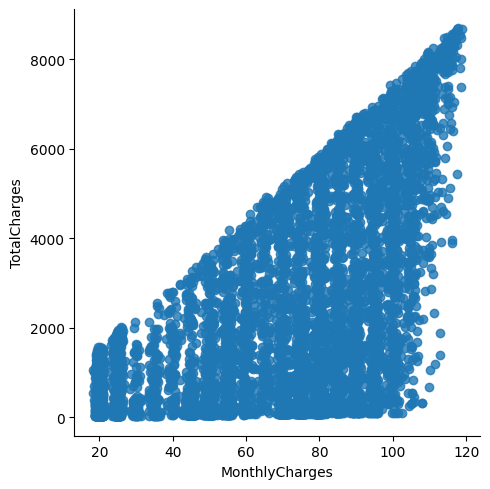

In [ ]:
sns.lmplot(data =new_df_dummies,x='MonthlyCharges',y='TotalCharges',fit_reg=False)

In [ ]:
new_df_dummies['MonthlyCharges'].corr(new_df_dummies['TotalCharges'])

np.float64(0.6510648032262027)

total charges increase as montly chrges increase as expected

Churn by Montly charges and total charges

/tmp/ipykernel_6328/879726707.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Mth = sns.kdeplot(new_df_dummies.MonthlyCharges[(new_df_dummies['Churn']== 0)], color ="Red", shade = True)
/tmp/ipykernel_6328/879726707.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Mth = sns.kdeplot(new_df_dummies.MonthlyCharges[(new_df_dummies['Churn']==1)], color ="Blue", shade = True)


Text(0.5, 1.0, 'Montly Charges by Churn')

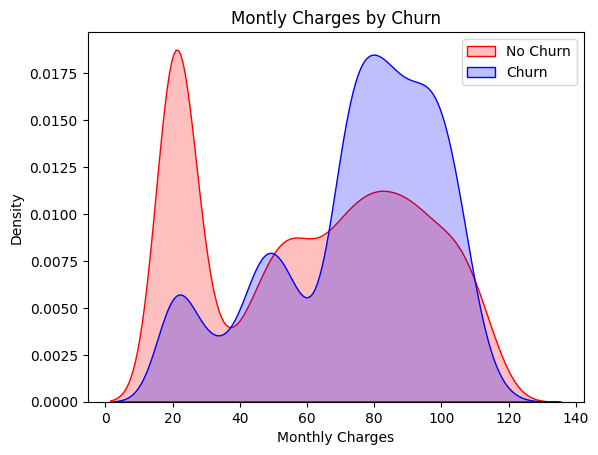

In [ ]:
Mth = sns.kdeplot(new_df_dummies.MonthlyCharges[(new_df_dummies['Churn']== 0)], color ="Red", shade = True)
Mth = sns.kdeplot(new_df_dummies.MonthlyCharges[(new_df_dummies['Churn']==1)], color ="Blue", shade = True)

Mth.legend(["No Churn","Churn"], loc='upper right')
Mth.set_ylabel('Density')
Mth.set_xlabel('Monthly Charges')
Mth.set_title("Montly Charges by Churn")

Insight: Churn is high when Montly charges are high

/tmp/ipykernel_6328/2491580319.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(new_df_dummies.TotalCharges[(new_df_dummies['Churn']== 0)], color ="Red", shade = True)
/tmp/ipykernel_6328/2491580319.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(new_df_dummies.TotalCharges[(new_df_dummies['Churn']==1)], color ="Blue", shade = True)


Text(0.5, 1.0, 'Total Charges by Churn')

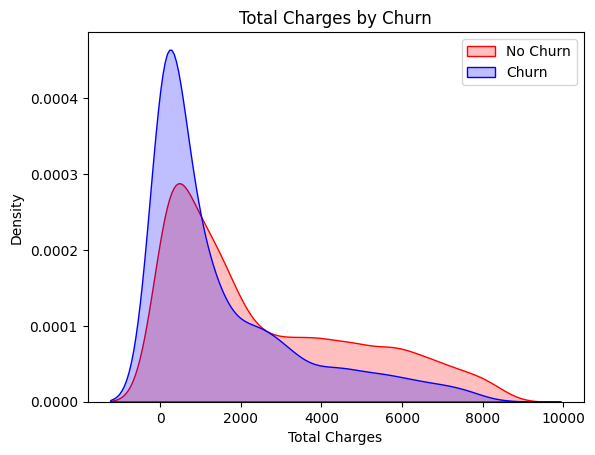

In [ ]:
Tot = sns.kdeplot(new_df_dummies.TotalCharges[(new_df_dummies['Churn']== 0)], color ="Red", shade = True)
Tot = sns.kdeplot(new_df_dummies.TotalCharges[(new_df_dummies['Churn']==1)], color ="Blue", shade = True)

Tot.legend(["No Churn","Churn"], loc='upper right')
Tot.set_ylabel('Density')
Tot.set_xlabel('Total Charges')
Tot.set_title("Total Charges by Churn")

Insight: Total Charges are low Churners are high, even though they are correlated montly charges and total charges as positively correlated


However if we combine  the ingiths of 3 paramets that i tenture, monthly charges and toal charges then the picture is bit clear; higher montly charge at lower tenure into lower total charges. hence, all these 3 factors higher montly charges, lower tenure and lower total charges are linked to high churn

#Correlation of all predictors 9columns) with churn

<Axes: >

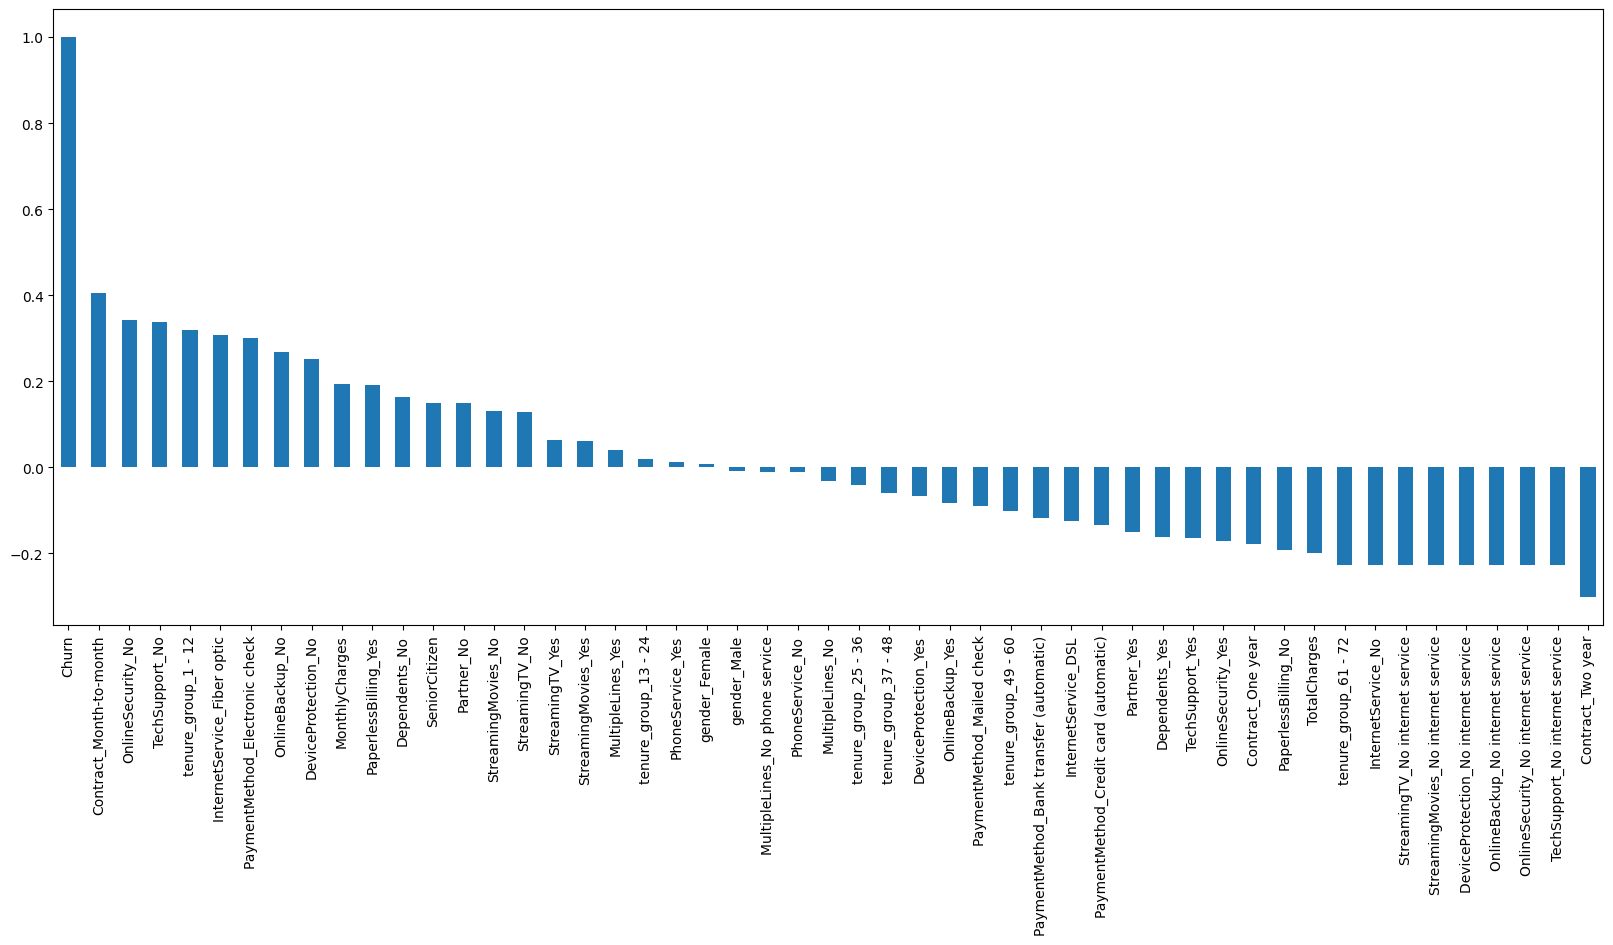

In [ ]:
plt.figure(figsize=(20,8))
new_df_dummies.corr()['Churn'].sort_values(ascending= False).plot(kind='bar')

Montly contractors are more likely to churn, people wh dont have online security are churners, tech support no are high churner, people who are in the comoany betwen 1-12 months new custmers, more likely to churn, paymeny electrnoic chek more likely to churn

people who are in te  institution for a longer time are non churners the negative part of the graph

set a threshold and then choose set of predictors

# heatmap

<Axes: >

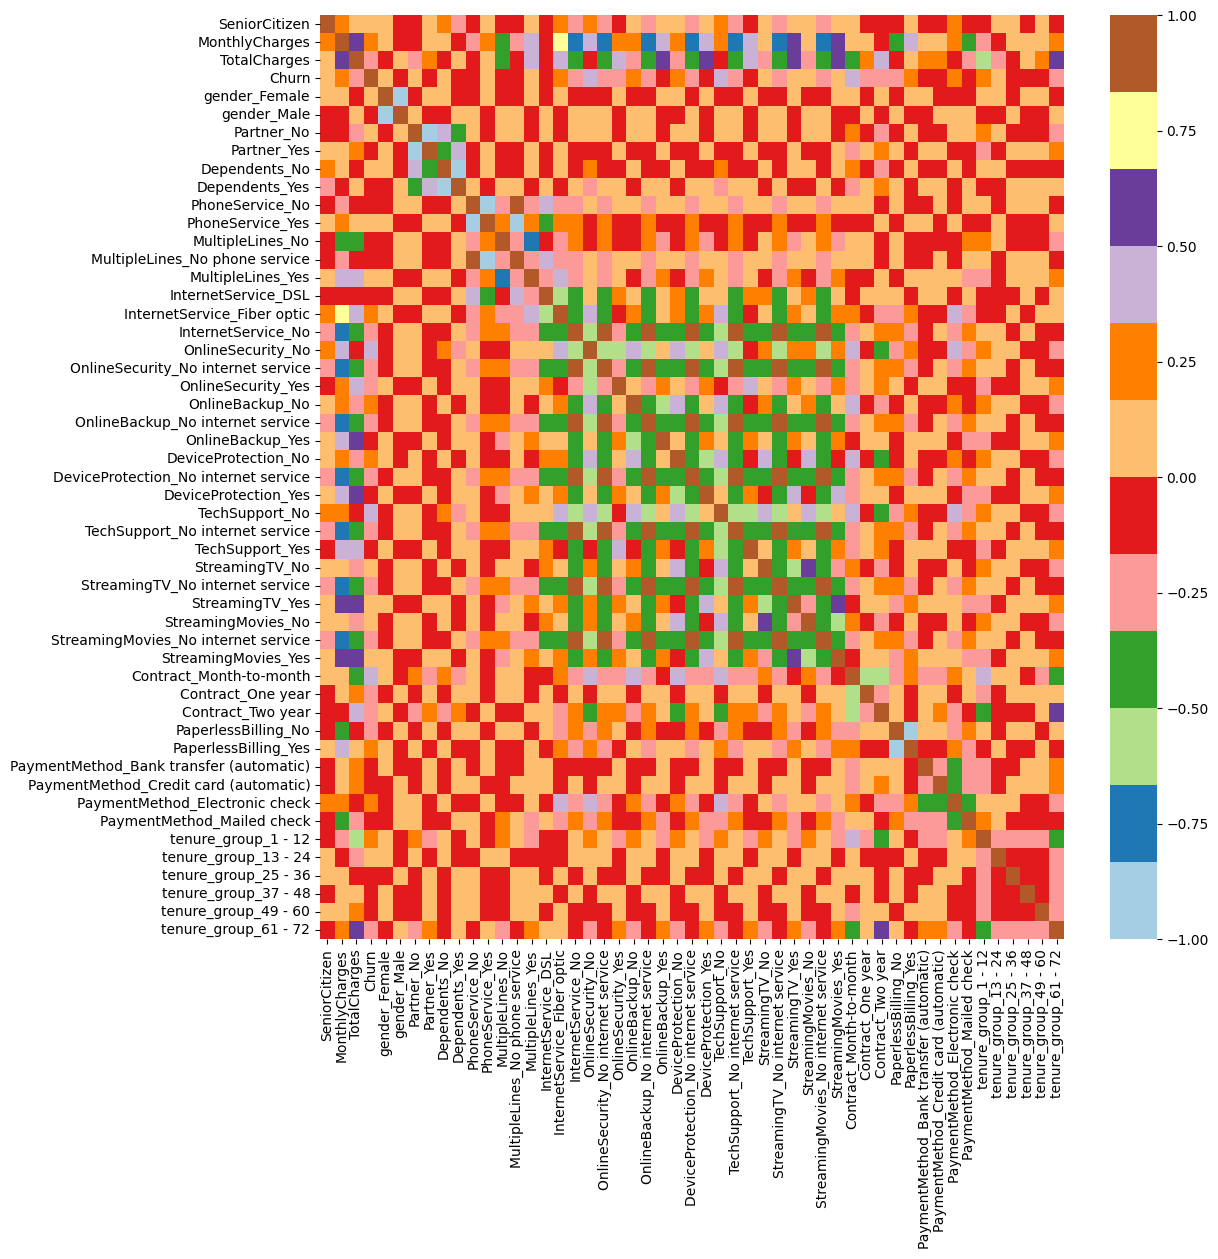

In [ ]:
plt.figure(figsize=(12,12))
sns.heatmap(new_df_dummies.corr(),cmap="Paired")

#Bivariate Analysis



In [ ]:
new_df1_target0 = new_df[new_df['Churn']== 0]
new_df1_target1 = new_df[new_df['Churn']== 1]

In [ ]:
len(new_df1_target1)

1869

In [ ]:
len(new_df1_target0)

5163

In [ ]:
def uniplot(df, col, title, hue=None):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd

    sns.set_style('whitegrid')
    sns.set_context('talk')


    plt.rcParams["axes.labelsize"] = 20
    plt.rcParams["axes.titlesize"] = 22
    plt.rcParams["axes.titlepad"] = 30

    fig, ax = plt.subplots()


    base_width = len(df[col].unique()) + 6
    if hue:
        base_width += 2 * df[hue].nunique()

    fig.set_size_inches(base_width, 8)

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index,
        hue=hue,
        palette='bright',
        ax=ax
    )

    plt.xticks(rotation=45)
    plt.yscale('log')
    plt.title(title)

    plt.tight_layout()
    plt.show()

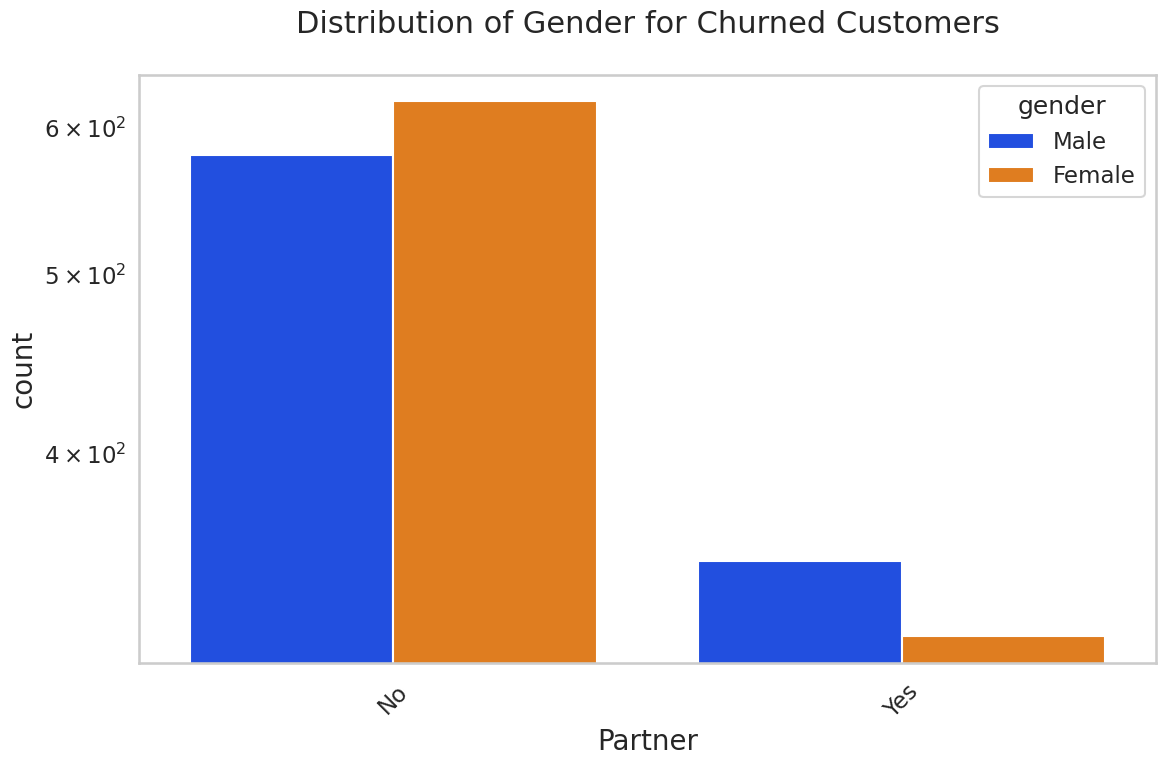

In [ ]:
uniplot(new_df1_target1,col='Partner', title='Distribution of Gender for Churned Customers', hue='gender')

Female with more partners are likely to churn as per te graph

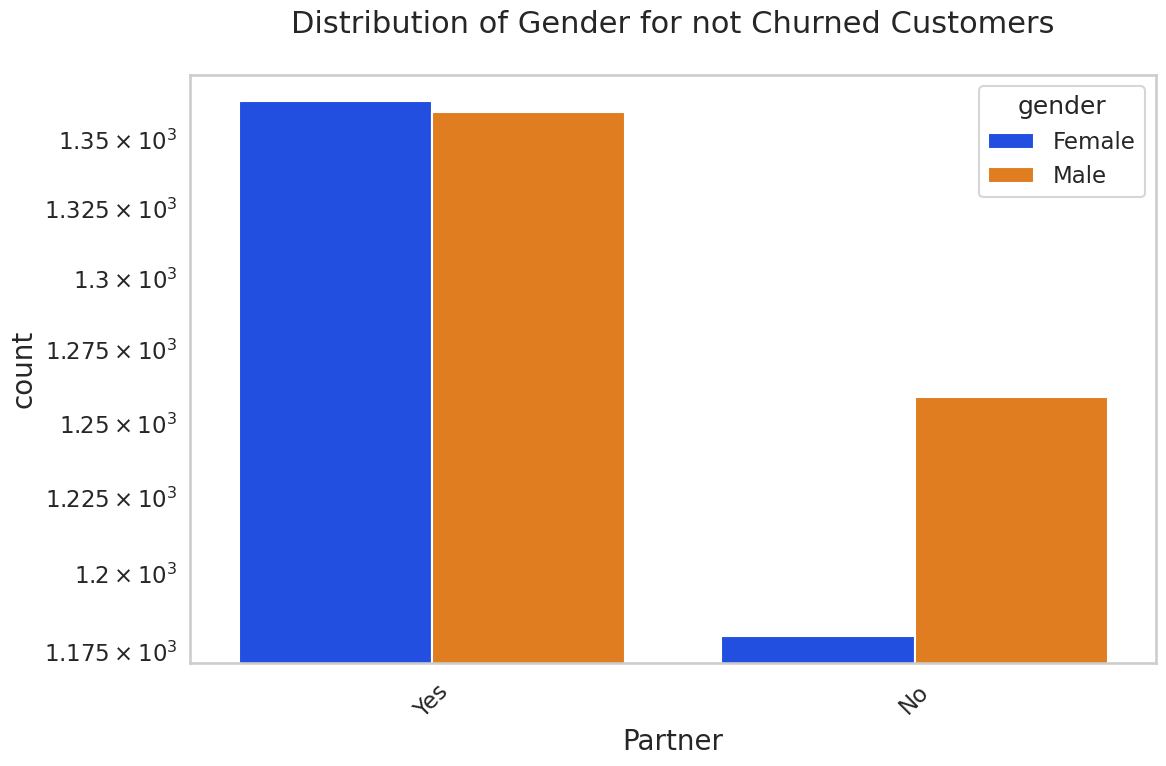

In [ ]:
uniplot(new_df1_target0,col='Partner', title='Distribution of Gender for not Churned Customers', hue='gender')

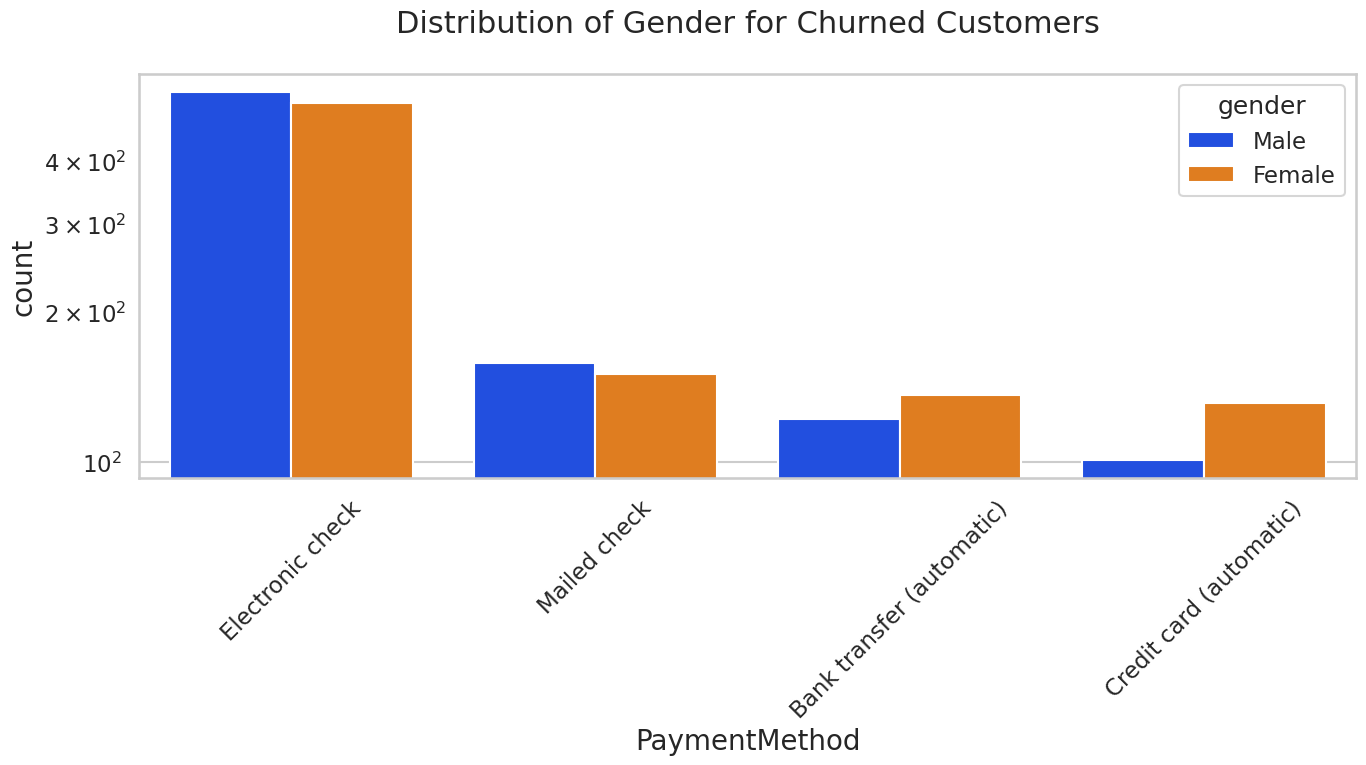

In [ ]:
uniplot(new_df1_target1,col='PaymentMethod', title='Distribution of Gender for Churned Customers', hue='gender')

more female who pay via credit cards are more into churning as per data
bank tranfer a little bit more

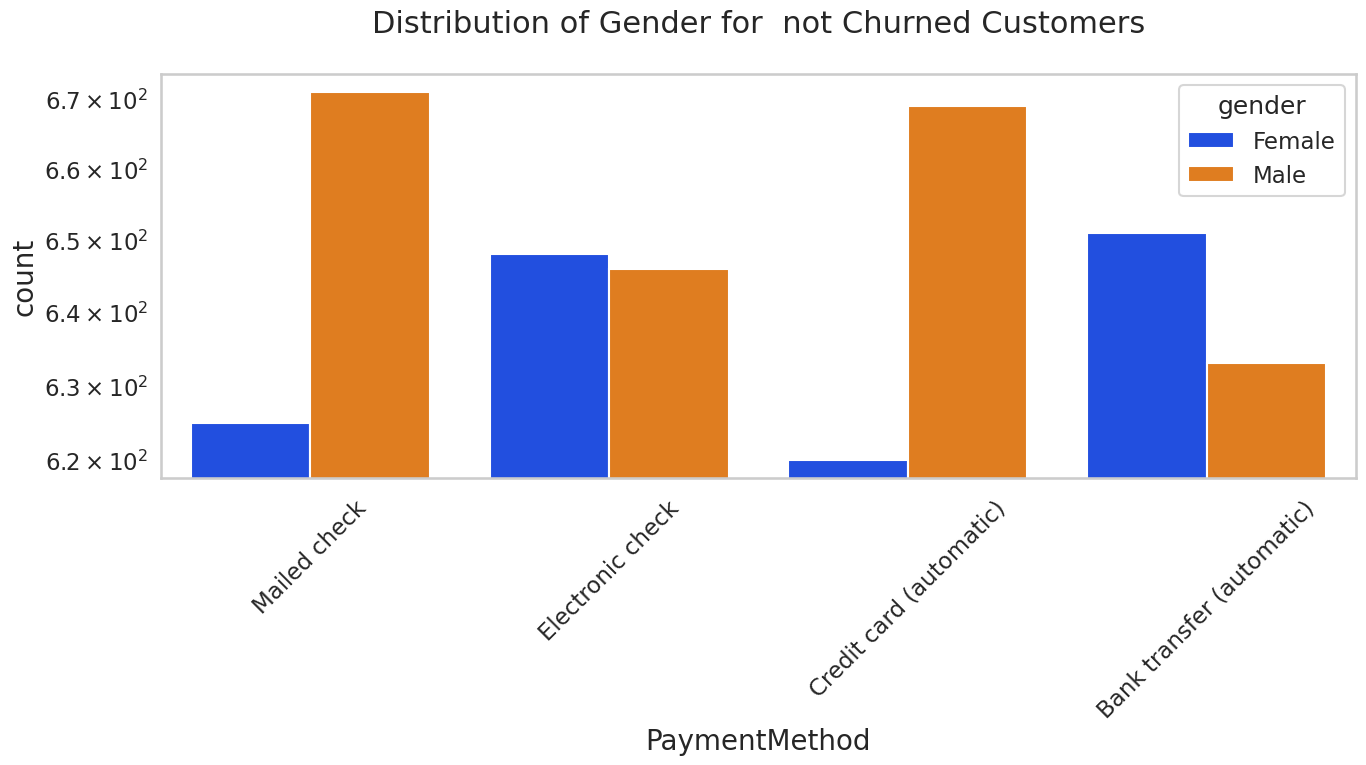

In [ ]:
uniplot(new_df1_target0,col='PaymentMethod', title='Distribution of Gender for  not Churned Customers', hue='gender')

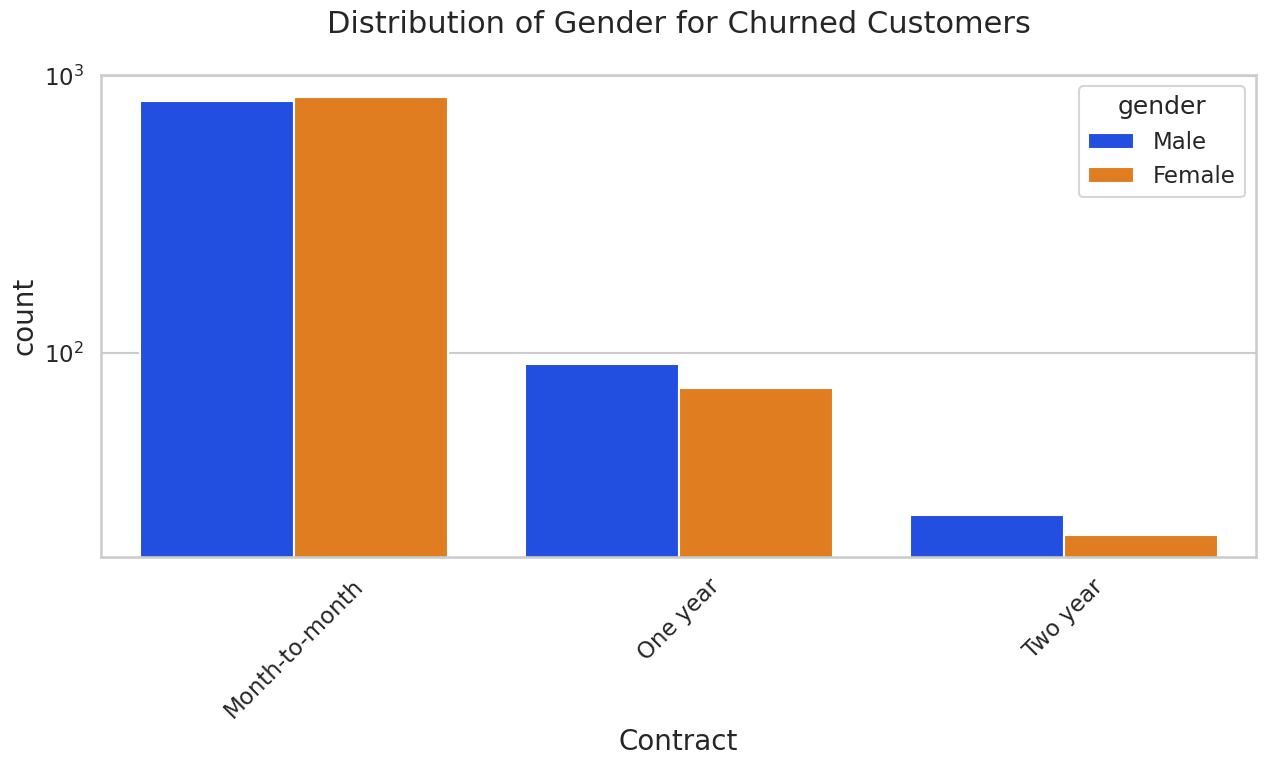

In [ ]:
uniplot(new_df1_target1,col='Contract', title='Distribution of Gender for Churned Customers', hue='gender')

not great insight but in two yearly contact more mails are likely to churn

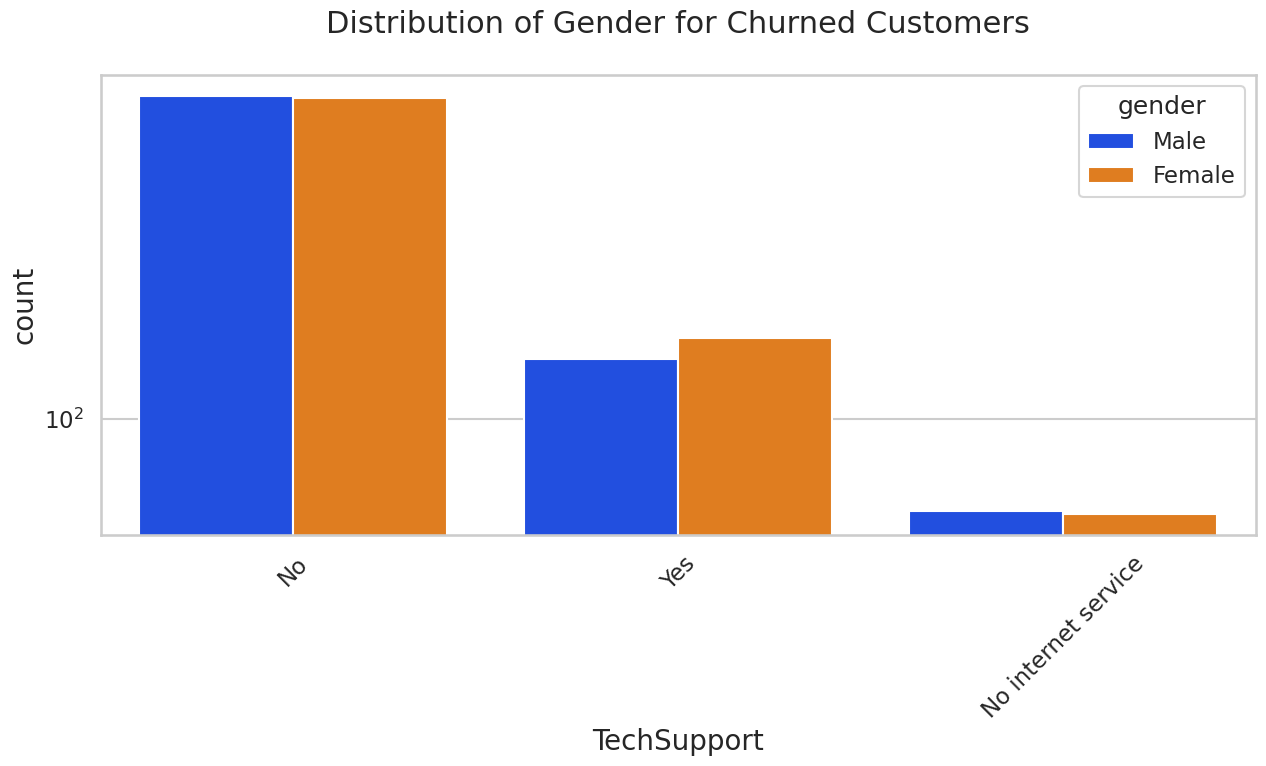

In [ ]:
uniplot(new_df1_target1,col='TechSupport', title='Distribution of Gender for Churned Customers', hue='gender')

# Predictive Modeling

1. KNN classifiation supervised algorithm

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.dropna(how='any',inplace=True)

In [ ]:
df.Churn.value_counts()/len(df)*100

,count
Churn,
No,73.421502
Yes,26.578498


divide data into training and test set , we create models with them now and then we compare predictions of each model, we will create only one model as of now KNN model:-

before this we will divide the data into X variables and Y variables, before split , Y_ churn column and X will beither data

In [ ]:
X = df.drop(['customerID', 'Churn'],axis=1)

In [ ]:
Y = df.Churn.values

In [ ]:
print(X)

      gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0     Female              0     Yes         No       1           No   
1       Male              0      No         No      34          Yes   
2       Male              0      No         No       2          Yes   
3       Male              0      No         No      45           No   
4     Female              0      No         No       2          Yes   
...      ...            ...     ...        ...     ...          ...   
7038    Male              0     Yes        Yes      24          Yes   
7039  Female              0     Yes        Yes      72          Yes   
7040  Female              0     Yes        Yes      11           No   
7041    Male              1     Yes         No       4          Yes   
7042    Male              0      No         No      66          Yes   

         MultipleLines InternetService OnlineSecurity OnlineBackup  \
0     No phone service             DSL             No          Yes   
1      

In [ ]:
print(Y)

['No' 'No' 'Yes' ... 'No' 'Yes' 'No']


In [ ]:
X.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')

we check for categorical attributes and change them to numerical attributes using dummy encoding (feature encoding)

In [ ]:
X = pd.get_dummies(X, columns=['gender', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'], drop_first= True) # we get rid of one feature for dummy encoding)

In [ ]:
X.head(1)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [ ]:
#spliiting the data now

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.25) #test set is 25%

In [ ]:
len(X_train)

5274

In [ ]:
len(X_test)

1758

fit_tranform we use trai ing data is to be ft on the model, hence only training data will be passed onto the model, based on this test data is scaled but only training data reaches to the model

In [ ]:
# Feature scaling : scale down the features, Standarisation and normalisation

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)




In [ ]:
X_train_sc

array([[-0.43863806,  0.05738792,  1.10146378, ..., -0.53334957,
         1.40401838, -0.53364283],
       [-0.43863806, -1.27789384, -0.46285337, ..., -0.53334957,
         1.40401838, -0.53364283],
       [-0.43863806,  0.05738792,  1.3572014 , ..., -0.53334957,
        -0.71224139, -0.53364283],
       ...,
       [-0.43863806, -1.19696767,  1.44355436, ..., -0.53334957,
         1.40401838, -0.53364283],
       [-0.43863806, -1.19696767, -0.47613844, ..., -0.53334957,
        -0.71224139,  1.87391257],
       [ 2.27978394,  0.21924025,  1.00514701, ..., -0.53334957,
         1.40401838, -0.53364283]])

In [ ]:
X_test_sc

array([[-0.43863806, -1.19696767, -0.6554869 , ..., -0.53334957,
        -0.71224139,  1.87391257],
       [-0.43863806, -0.10446442,  0.19641829, ..., -0.53334957,
         1.40401838, -0.53364283],
       [-0.43863806,  1.3117435 ,  1.15792533, ..., -0.53334957,
         1.40401838, -0.53364283],
       ...,
       [-0.43863806,  0.01692483,  0.48702923, ..., -0.53334957,
         1.40401838, -0.53364283],
       [-0.43863806, -0.387706  ,  0.701251  , ..., -0.53334957,
         1.40401838, -0.53364283],
       [-0.43863806, -1.07557842, -1.29815223, ..., -0.53334957,
        -0.71224139,  1.87391257]])

#Creating classfiers now

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

In [ ]:
# knn classifier

from sklearn.neighbors import KNeighborsClassifier

# initiating the classifier

model = KNeighborsClassifier() #usinf default configuation , hyper-parameter optimisation can also be done

#Passing the data to classifier
model.fit(X_train_sc, Y_train)

KNeighborsClassifier()

In [ ]:
y_pred = model.predict(X_test_sc)

In [ ]:
y_pred

array(['No', 'No', 'No', ..., 'No', 'Yes', 'No'], dtype=object)

there are mistakes if we compare

In [ ]:
Y_test

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

Checking the mistakes

In [ ]:
# classification metrics to check how the model is behaving

from sklearn.metrics import accuracy_score

round(accuracy_score(Y_test,y_pred) *100,2)

75.26

## new data prediction

In [ ]:
X_test_sc

array([[-0.43863806, -1.19696767, -0.6554869 , ..., -0.53334957,
        -0.71224139,  1.87391257],
       [-0.43863806, -0.10446442,  0.19641829, ..., -0.53334957,
         1.40401838, -0.53364283],
       [-0.43863806,  1.3117435 ,  1.15792533, ..., -0.53334957,
         1.40401838, -0.53364283],
       ...,
       [-0.43863806,  0.01692483,  0.48702923, ..., -0.53334957,
         1.40401838, -0.53364283],
       [-0.43863806, -0.387706  ,  0.701251  , ..., -0.53334957,
         1.40401838, -0.53364283],
       [-0.43863806, -1.07557842, -1.29815223, ..., -0.53334957,
        -0.71224139,  1.87391257]])

In [ ]:
X_test.head(1)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
5447,0,3,44.75,148.05,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
data = [[0,2,87,178,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,1]]

In [ ]:
data_sc = sc.transform(data)

single = model.predict(data_sc)
print(single)

['Yes']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
data_sc = sc.transform(data)

single = model.predict_proba(data_sc)
print(single)

[[0.4 0.6]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Descion tree classifiers

In [ ]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [ ]:
 X

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,True,True,True,True,False,True,...,False,True,False,True,True,False,True,False,False,True
7039,0,72,103.20,7362.90,False,True,True,True,False,True,...,False,True,False,True,True,False,True,True,False,False
7040,0,11,29.60,346.45,False,True,True,False,True,False,...,False,False,False,False,False,False,True,False,True,False
7041,1,4,74.40,306.60,True,True,False,True,False,True,...,False,False,False,False,False,False,True,False,False,True


In [ ]:
Y

array(['No', 'No', 'Yes', ..., 'No', 'Yes', 'No'], dtype=object)

In [ ]:
X.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [ ]:
X.head(1)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y, test_size=0.30)

In [ ]:
len(X_train)

4922

In [ ]:
# Feature scaling : scale down the features, Standarisation and normalisation

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)




In [ ]:
# DT classifier

from sklearn.tree import DecisionTreeClassifier

# initiating the classifier

model_dt = DecisionTreeClassifier() #usinf default configuation , hyper-parameter optimisation can also be done

#Passing the data to classifier
model_dt.fit(X_train_sc, Y_train)

DecisionTreeClassifier()

In [ ]:
y_pred_dt = model_dt.predict(X_test_sc)

In [ ]:
# classification metrics to check how the model is behaving

from sklearn.metrics import accuracy_score

round(accuracy_score(Y_test,y_pred_dt) *100,2)

72.94

#Random forest classifier

In [ ]:
# Rnadom Forest classifier

from sklearn.ensemble import RandomForestClassifier

# initiating the classifier

model_rf = RandomForestClassifier(n_estimators=300) #usinf default configuation , hyper-parameter optimisation can also be done

#Passing the data to classifier
model_rf.fit(X_train_sc, Y_train)

RandomForestClassifier(n_estimators=300)

In [ ]:
y_pred_rf = model_rf.predict(X_test_sc)

In [ ]:
# classification metrics to check how the model is behaving

from sklearn.metrics import accuracy_score

round(accuracy_score(Y_test,y_pred_rf) *100,2)

79.81

#Ensemble Learning Boosting

In [ ]:
# ADA BOOST classifier

from sklearn.ensemble import AdaBoostClassifier

# initiating the classifier

model_ada = AdaBoostClassifier(n_estimators=100) #usinf default configuation , hyper-parameter optimisation can also be done

#Passing the data to classifier
model_ada.fit(X_train_sc, Y_train)

AdaBoostClassifier(n_estimators=100)

In [ ]:
y_pred_ada = model_ada.predict(X_test_sc)

In [ ]:
# classification metrics to check how the model is behaving

from sklearn.metrics import accuracy_score

round(accuracy_score(Y_test,y_pred_ada) *100,2)

82.46